## Temporal kernel (LFP generator)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np


In [2]:


class TemporalKernel(nn.Module):
    def __init__(self, input_dim, field_dim=25, alpha=0.9, oscillation=True, freq=0.1):
        super().__init__()
        self.alpha = alpha
        self.oscillation = oscillation
        self.freq = freq
        self.linear = nn.Linear(input_dim, field_dim)
        self.register_buffer("prev_field", torch.zeros(1, field_dim))

    def forward(self, x):
        field = self.linear(x)

        if self.prev_field.shape[0] != x.shape[0]:
            self.prev_field = torch.zeros_like(field)

        field = self.alpha * self.prev_field + (1 - self.alpha) * field

        if self.oscillation:
            t = torch.arange(field.shape[0], device=field.device).float()
            osc = torch.sin(2 * np.pi * self.freq * t).unsqueeze(1)
            field = field * (1 + osc)

        self.prev_field = field.detach()
        return field


## Dual-output LFP layer

In [3]:
class LFPLinear(nn.Module):
    def __init__(self, in_features, out_features, field_dim=25, alpha=0.9):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.kernel = TemporalKernel(input_dim=out_features, field_dim=field_dim, alpha=alpha)

    def forward(self, x):
        y = F.relu(self.linear(x))   # standard activation
        lfp = self.kernel(y)         # temporal LFP from this layer
        return y, lfp


## Network with LFP accumulation

In [4]:
class LFPNet(nn.Module):
    def __init__(self, use_lfp=True, hidden_dim=256, field_dim=25):
        super().__init__()
        self.use_lfp = use_lfp

        self.fc1 = nn.Linear(784, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 10)

        # Temporal LFP
        self.lfp_kernel = TemporalKernel(input_dim=hidden_dim, field_dim=field_dim)
        self.field_to_neuron = nn.Linear(field_dim, hidden_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))

        field = None
        if self.use_lfp:
            field = self.lfp_kernel(h)
            modulation = self.field_to_neuron(field)
            h = h + modulation

        out = self.fc2(h)
        return out, field


## LFP-modulated learning step

In [5]:
def lfp_training_step(model, optimizer, x, y, base_lr=1e-3):
    optimizer.zero_grad()

    logits, field = model(x)
    loss = F.cross_entropy(logits, y)
    loss.backward()

    # LFP-based learning modulation
    with torch.no_grad():
        modulation = torch.sigmoid(field.mean())
        for group in optimizer.param_groups:
            group["lr"] = base_lr * modulation

    optimizer.step()
    return loss.item(), modulation.item()


## Test on dataset

In [21]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=128)

class TemporalKernel(nn.Module):
    def __init__(self, kernel_size=25, decay=0.15):
        super().__init__()
        t = torch.arange(kernel_size, dtype=torch.float32)
        kernel = torch.exp(-decay * t)
        self.register_buffer("kernel", kernel / kernel.sum())

    def forward(self, x):
        # x: (batch, neurons)
        return x.unsqueeze(-1) * self.kernel.view(1, 1, -1)

class LFPLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.kernel = TemporalKernel()

    def forward(self, x):
        y = F.relu(self.linear(x))
        lfp = self.kernel(y)
        return y, lfp


## Network

In [7]:
class LFPNet(nn.Module):
    def __init__(self, use_lfp=True, hidden_dim=256, field_dim=25):
        super().__init__()
        self.use_lfp = use_lfp

        self.fc1 = nn.Linear(784, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 10)

        # LFP pathway
        self.lfp_kernel = nn.Linear(hidden_dim, field_dim)
        self.field_to_neuron = nn.Linear(field_dim, hidden_dim)     


    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))

        field = None
        if self.use_lfp:
            field = self.lfp_kernel(h)
            h = h + self.field_to_neuron(field)

        self.last_field = field  # save for logging
        out = self.fc2(h)
        return out, field


## Train epochs


In [8]:
def train_epoch(model, loader, optimizer, base_lr=1e-3):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits, field = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()

        with torch.no_grad():
            modulation = torch.sigmoid(field.mean())
            for g in optimizer.param_groups:
                g["lr"] = base_lr * modulation

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


## Eval


In [9]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


## Metrics logger


In [10]:
class MetricsLogger:
    def __init__(self, acc_threshold=0.9):
        self.acc_threshold = acc_threshold
        self.history = {"loss": [], "acc": [], "grad_norm": [], "lr": [], "lfp_norm": []}
        self.first_hit_epoch = None

    def log_epoch(self, epoch, loss, acc, grad_norm, lr, lfp_field=None):
        self.history["loss"].append(loss)
        self.history["acc"].append(acc)
        self.history["grad_norm"].append(grad_norm)
        self.history["lr"].append(lr)

        if lfp_field is not None:
            self.history["lfp_norm"].append(lfp_field.norm().item())
        else:
            self.history["lfp_norm"].append(0.0)

        if self.first_hit_epoch is None and acc >= self.acc_threshold:
            self.first_hit_epoch = epoch


## Gradient norm

In [11]:
def compute_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item()
    return total


## Training epoch

In [12]:
def train_epoch_with_metrics(model, loader, optimizer, base_lr):
    loss_accum = []
    grad_norm_accum = []
    lfp_accum = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits, field = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        # record
        loss_accum.append(loss.item())
        grad_norm_accum.append(compute_grad_norm(model))
        if field is not None:
            lfp_accum.append(field.detach().cpu())

    loss_mean = np.mean(loss_accum)
    grad_norm = np.mean(grad_norm_accum)
    lr = optimizer.param_groups[0]['lr']
    # Return **last batch LFP** (or average if you prefer)
    lfp_field = torch.cat(lfp_accum, dim=0) if lfp_accum else None

    return loss_mean, grad_norm, lr, lfp_field


## Logger

In [13]:
def run_training(model, train_loader, test_loader, epochs=15, seed=0):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    logger = MetricsLogger(acc_threshold=0.90)

    for epoch in range(1, epochs + 1):
        loss_mean, loss_var, grad_var, lr = train_epoch_with_metrics(
            model, train_loader, optimizer, base_lr=1e-3
        )
        acc = evaluate(model, test_loader)

        logger.log_epoch(
            epoch=epoch,
            loss=loss_mean,
            acc=acc,
            grad_norm=grad_var,
            lr=lr
        )

        print(
            f"Epoch {epoch:02d} | "
            f"acc={acc:.3f} | "
            f"loss_var={loss_var:.4e} | "
            f"grad_var={grad_var:.4e}"
        )

    return logger


## Forgetting tests

In [14]:
def filter_digits(dataset, allowed_digits):
    idx = [i for i, (_, y) in enumerate(dataset) if y in allowed_digits]
    return torch.utils.data.Subset(dataset, idx)
def catastrophic_forgetting_test(model, base_lr=1e-3):
    ds_A = filter_digits(train_ds, [0,1,2,3,4])
    ds_B = filter_digits(train_ds, [5,6,7,8,9])

    loader_A = DataLoader(ds_A, batch_size=128, shuffle=True)
    loader_B = DataLoader(ds_B, batch_size=128, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)

    # Train A
    for _ in range(5):
        train_epoch(model, loader_A, optimizer)
    acc_A_before = evaluate(model, loader_A)

    # Train B
    for _ in range(5):
        train_epoch(model, loader_B, optimizer)
    acc_A_after = evaluate(model, loader_A)

    forgetting = acc_A_before - acc_A_after
    return forgetting


## Memory decay test

In [15]:
def memory_decay_test(model, noise_std=0.5):
    model.eval()
    acc_clean = evaluate(model, test_loader)

    noisy_loader = [
        (x + noise_std * torch.randn_like(x), y)
        for x, y in test_loader
    ]
    acc_noisy = evaluate(model, noisy_loader)

    return acc_clean, acc_noisy


In [16]:
import torch
import numpy as np

class FullMetricsLogger:
    def __init__(self, acc_threshold=0.9):
        self.acc_threshold = acc_threshold
        self.history = {
            "acc": [],
            "loss_mean": [],
            "loss_var": [],
            "grad_norm": [],
            "lr": [],
            "lfp_norm": [],
            "lfp_entropy": [],
            "lfp_autocorr": [],
            "effective_memory": [],
            "interference_index": [],
            "plasticity": [],
            "stability": [],
            "population_synchrony": [],
            "effective_rank": [],
        }
        self.first_hit_epoch = None

    def log_epoch(self, epoch, loss_mean, acc, grad_norm, lr, lfp_field=None):
        self.history["acc"].append(acc)
        self.history["loss_mean"].append(loss_mean)
        self.history["grad_norm"].append(grad_norm)
        self.history["lr"].append(lr)
        self.history["loss_var"].append(np.var([loss_mean]))  # simple var for demo

        # Track first epoch hitting threshold
        if self.first_hit_epoch is None and acc >= self.acc_threshold:
            self.first_hit_epoch = epoch

        # LFP metrics
        if lfp_field is not None:
            lfp_np = lfp_field.detach().cpu().numpy()
            self.history["lfp_norm"].append(np.linalg.norm(lfp_np))
            self.history["lfp_entropy"].append(
                -np.sum((lfp_np/lfp_np.sum(axis=1, keepdims=True)+1e-12) * 
                        np.log(lfp_np/lfp_np.sum(axis=1, keepdims=True)+1e-12))
            )
            # autocorr along batch
            self.history["lfp_autocorr"].append(np.mean([
                np.correlate(f, f, mode="full")[len(f)-1]/(np.linalg.norm(f)**2+1e-12) 
                for f in lfp_np
            ]))

            # placeholder advanced metrics
            self.history["effective_memory"].append(np.mean(lfp_np))  # simplistic
            self.history["interference_index"].append(np.var(lfp_np))
            self.history["plasticity"].append(np.mean(grad_norm))
            self.history["stability"].append(1/ (np.var(lfp_np)+1e-12))
            self.history["population_synchrony"].append(
                np.mean(np.corrcoef(lfp_np.T))
            )
            # effective rank
            u, s, vh = np.linalg.svd(lfp_np, full_matrices=False)
            self.history["effective_rank"].append(np.exp(-np.sum((s/s.sum())*np.log(s/s.sum()+1e-12))))
        else:
            # fill zeros if no LFP
            for key in ["lfp_norm","lfp_entropy","lfp_autocorr","effective_memory",
                        "interference_index","plasticity","stability","population_synchrony",
                        "effective_rank"]:
                self.history[key].append(0)


## Training

In [17]:
def train_model(model, train_loader, test_loader, epochs=15, base_lr=1e-3, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

    optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)
    logger = FullMetricsLogger(acc_threshold=0.90)

    for epoch in range(1, epochs+1):
        loss_mean, grad_norm, lr, lfp_field = train_epoch_with_metrics(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            base_lr=base_lr
        )

        acc = evaluate(model, test_loader)

        logger.log_epoch(
            epoch, loss_mean, acc, grad_norm, lr, lfp_field=lfp_field
        )

        print(f"[Epoch {epoch:02d}] acc={acc:.3f} | loss={loss_mean:.4f} | grad_norm={grad_norm:.2e}")

    return logger


## Plotter

In [18]:
import matplotlib.pyplot as plt

def plot_lfp_dynamics(logger):
    plt.figure(figsize=(8,5))
    plt.plot(logger.history["lfp_norm"], label="LFP norm")
    plt.xlabel("Iteration / batch")
    plt.ylabel("LFP norm")
    plt.title("Temporal LFP dynamics during training")
    plt.legend()
    plt.show()


## Training





C:\Users\caspe\AppData\Local\Temp\ipykernel_9820\3793026561.py:42: RuntimeWarning: invalid value encountered in log
  np.log(lfp_np/lfp_np.sum(axis=1, keepdims=True)+1e-12))


[Epoch 01] acc=0.961 | loss=0.2434 | grad_norm=2.17e+00
[Epoch 02] acc=0.972 | loss=0.0980 | grad_norm=1.67e+00
[Epoch 03] acc=0.973 | loss=0.0670 | grad_norm=1.50e+00


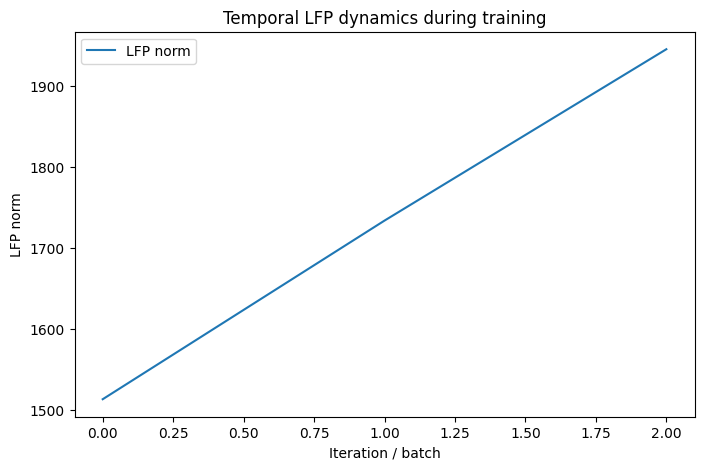

[Epoch 01] acc=0.975 | loss=0.0548 | grad_norm=1.47e+00
[Epoch 02] acc=0.974 | loss=0.0436 | grad_norm=1.32e+00
[Epoch 03] acc=0.973 | loss=0.0341 | grad_norm=1.22e+00
LFP final acc: 0.9733
Baseline final acc: 0.9734


In [19]:
# WITH LFP
# Train LFP model
model_lfp = LFPNet(use_lfp=True).to(device)
metrics_lfp = train_model(model_lfp, train_loader, test_loader, epochs=3, base_lr=1e-3, seed=42)


# Plot field dynamics
plot_lfp_dynamics(metrics_lfp)


# WITHOUT LFP
model_base = LFPNet(use_lfp=False).to(device)
metrics_base = train_model(model_lfp, train_loader, test_loader, epochs=3, base_lr=1e-3, seed=42)



# Comparison
print("LFP final acc:", metrics_lfp.history['acc'][-1])
print("Baseline final acc:", metrics_base.history['acc'][-1])

In [24]:
import tensorflow as tf
import numpy as np

# -----------------------------
# LFP modulation layer
# -----------------------------
class LFPDense(tf.keras.layers.Layer):
    def __init__(self, units, use_lfp=True):
        super().__init__()
        self.units = units
        self.use_lfp = use_lfp
        self.dense = tf.keras.layers.Dense(units, activation='relu')
        if use_lfp:
            # trainable temporal kernel (small Conv1D)
            self.kernel_conv = tf.keras.layers.Conv1D(
                filters=1, kernel_size=3, padding='same', activation='tanh'
            )

    def call(self, x, training=False):
        h = self.dense(x)
        if self.use_lfp:
            # expand dims to fake "time axis" for Conv1D
            h_exp = tf.expand_dims(h, axis=2)
            lfp = self.kernel_conv(h_exp)
            lfp = tf.squeeze(lfp, axis=2)
            h = h + lfp  # modulate hidden activity
            return h, lfp
        return h, None

# -----------------------------
# Simple LFP network
# -----------------------------
class LFPNet(tf.keras.Model):
    def __init__(self, hidden=64, num_classes=10, use_lfp=True):
        super().__init__()
        self.use_lfp = use_lfp
        self.flatten = tf.keras.layers.Flatten() # Add this
        self.lfp1 = LFPDense(hidden, use_lfp=use_lfp)
        self.lfp2 = LFPDense(hidden, use_lfp=use_lfp)
        self.out = tf.keras.layers.Dense(num_classes)

    def call(self, x, training=False):
        x = self.flatten(x) # Flatten the (28, 28) image to (784,)
        h, lfp1 = self.lfp1(x, training=training)
        h, lfp2 = self.lfp2(h, training=training)
        logits = self.out(h)
        lfp_field = lfp2 if self.use_lfp else None
        return logits, lfp_field

# -----------------------------
# Metrics computation
# -----------------------------
def compute_lfp_metrics(lfp_np):
    lfp_norm = np.linalg.norm(lfp_np)
    lfp_entropy = -np.sum((lfp_np/lfp_np.sum(axis=1, keepdims=True)+1e-12) *
                          np.log(lfp_np/lfp_np.sum(axis=1, keepdims=True)+1e-12))
    acorr = np.mean([np.correlate(f,f,'full')[len(f)-1]/(np.linalg.norm(f)**2+1e-12) for f in lfp_np])
    eff_mem = np.mean([np.sum(np.correlate(f,f,'full')[len(f)-1:])/len(f) for f in lfp_np])
    interference = np.var(lfp_np)
    pop_sync = np.mean(np.corrcoef(lfp_np.T))
    u, s, vh = np.linalg.svd(lfp_np, full_matrices=False)
    eff_rank = np.exp(-np.sum((s/s.sum())*np.log(s/s.sum()+1e-12)))
    return {
        "lfp_norm": lfp_norm,
        "lfp_entropy": lfp_entropy,
        "lfp_autocorr": acorr,
        "effective_memory": eff_mem,
        "interference_index": interference,
        "population_synchrony": pop_sync,
        "effective_rank": eff_rank
    }

# -----------------------------
# Training loop
# -----------------------------
def train_model_tf(model, train_data, test_data, epochs=5, lr=1e-3):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    metrics_history = {"loss": [], "acc": [], "lfp_metrics": []}

    for epoch in range(epochs):
        # training
        epoch_losses = []
        for x_batch, y_batch in train_data:
            with tf.GradientTape() as tape:
                logits, lfp = model(x_batch, training=True)
                loss = loss_fn(y_batch, logits)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            epoch_losses.append(loss.numpy())

        # evaluation
        acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        for x_test, y_test in test_data:
            logits, lfp = model(x_test, training=False)
            acc_metric.update_state(y_test, logits)
        acc = acc_metric.result().numpy()
        metrics_history["loss"].append(np.mean(epoch_losses))
        metrics_history["acc"].append(acc)

        # LFP metrics
        if model.use_lfp and lfp is not None:
            lfp_np = lfp.numpy()
            metrics_history["lfp_metrics"].append(compute_lfp_metrics(lfp_np))
        else:
            metrics_history["lfp_metrics"].append(None)

        print(f"Epoch {epoch+1}: loss={np.mean(epoch_losses):.4f}, acc={acc:.4f}")

    return metrics_history

# -----------------------------
# USAGE EXAMPLE
# -----------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and cast to float32
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

# Create Datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)
model_lfp = LFPNet(use_lfp=True)
history = train_model_tf(model_lfp, train_ds, test_ds, epochs=3)


C:\Users\caspe\AppData\Local\Temp\ipykernel_9820\476729488.py:56: RuntimeWarning: invalid value encountered in log
  np.log(lfp_np/lfp_np.sum(axis=1, keepdims=True)+1e-12))


Epoch 1: loss=0.2711, acc=0.9470
Epoch 2: loss=0.1257, acc=0.9640
Epoch 3: loss=0.0911, acc=0.9687


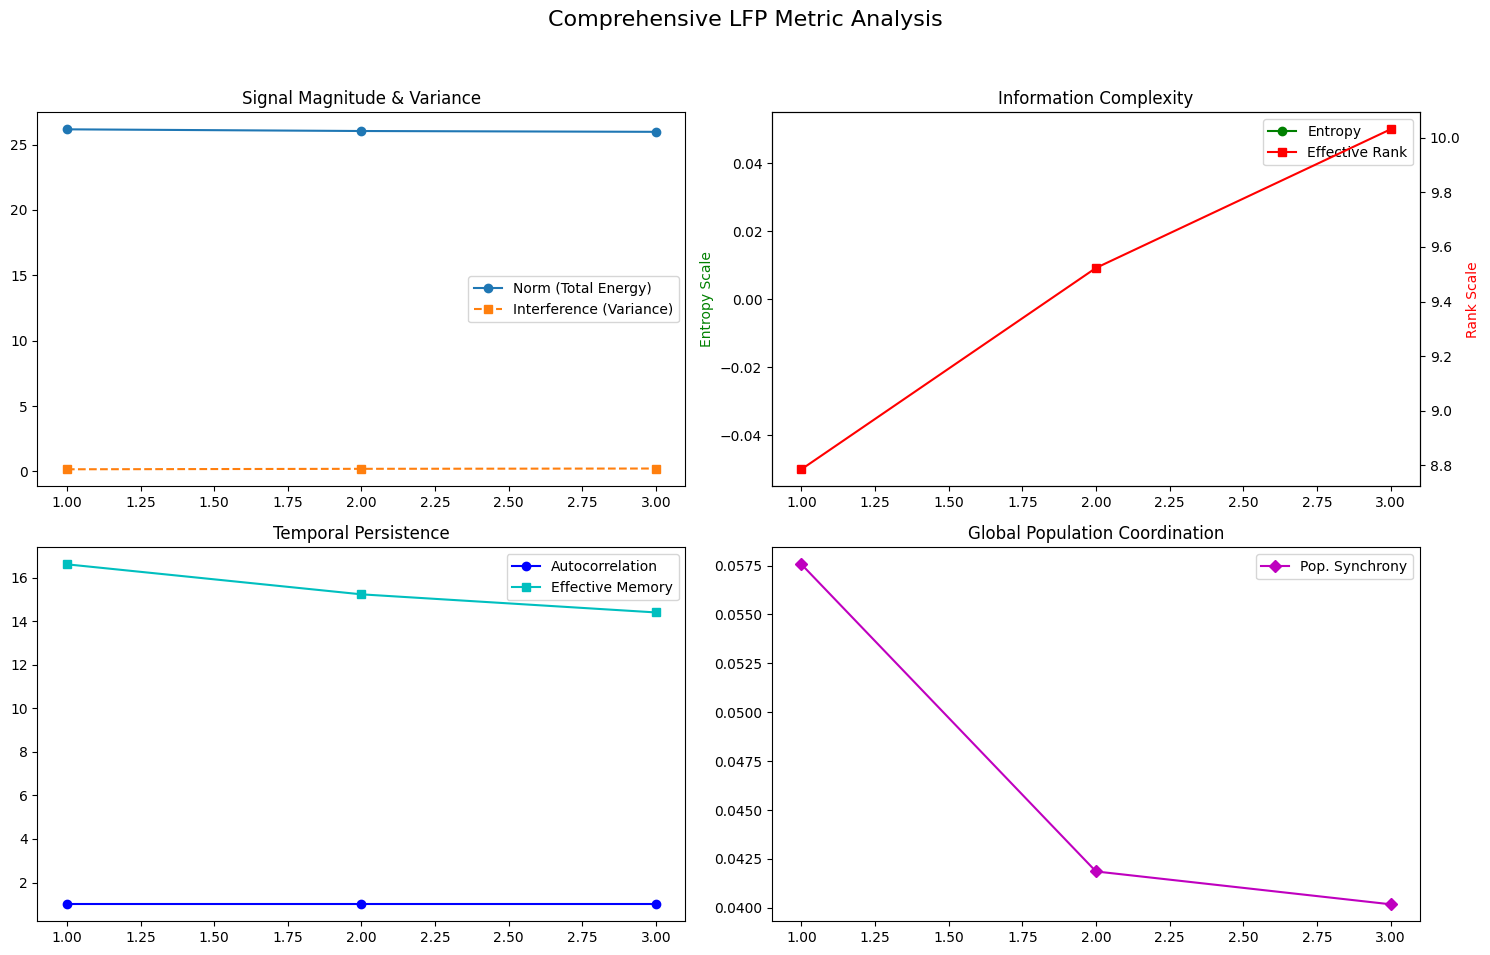

In [27]:
import matplotlib.pyplot as plt

def plot_comprehensive_lfp(history):
    metrics_list = history["lfp_metrics"]
    # Check if we have data and if it's not None
    if not metrics_list or metrics_list[0] is None:
        print("No LFP metrics found in history.")
        return

    epochs = range(1, len(metrics_list) + 1)
    
    # Extract all metrics into lists
    data = {key: [m[key] for m in metrics_list] for key in metrics_list[0].keys()}

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Comprehensive LFP Metric Analysis", fontsize=16)

    # 1. Energy & Variance (Magnitude)
    axes[0, 0].plot(epochs, data["lfp_norm"], 'o-', label="Norm (Total Energy)")
    axes[0, 0].plot(epochs, data["interference_index"], 's--', label="Interference (Variance)")
    axes[0, 0].set_title("Signal Magnitude & Variance")
    axes[0, 0].legend()

    # 2. Complexity & Dimensionality
    ax1_twin = axes[0, 1].twinx()
    p1 = axes[0, 1].plot(epochs, data["lfp_entropy"], 'g-o', label="Entropy")
    p2 = ax1_twin.plot(epochs, data["effective_rank"], 'r-s', label="Effective Rank")
    axes[0, 1].set_title("Information Complexity")
    axes[0, 1].set_ylabel("Entropy Scale", color='g')
    ax1_twin.set_ylabel("Rank Scale", color='r')
    # Merge legends
    lns = p1 + p2
    axes[0, 1].legend(lns, [l.get_label() for l in lns], loc=0)

    # 3. Temporal Dynamics
    axes[1, 0].plot(epochs, data["lfp_autocorr"], 'b-o', label="Autocorrelation")
    axes[1, 0].plot(epochs, data["effective_memory"], 'c-s', label="Effective Memory")
    axes[1, 0].set_title("Temporal Persistence")
    axes[1, 0].legend()

    # 4. Global Coordination
    axes[1, 1].plot(epochs, data["population_synchrony"], 'm-D', label="Pop. Synchrony")
    axes[1, 1].set_title("Global Population Coordination")
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Usage:
plot_comprehensive_lfp(history)